In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
mnist = fetch_openml("mnist_784", version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
X, y = mnist["data"], mnist["target"]
X = X.to_numpy()
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


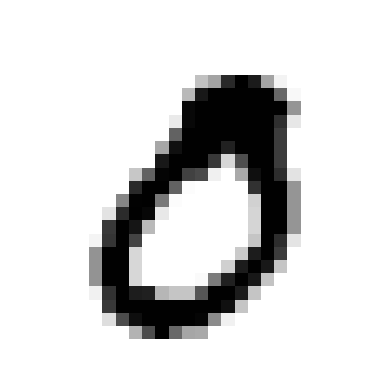

In [5]:
intance_feature = X[75]
intance_feature_image = intance_feature.reshape(28, 28)

plt.imshow(intance_feature_image, cmap="binary")
plt.axis("off")
plt.show()


# 5-Detector

Criaremos um identificador binario, que consegue identificar se um caractere é o numero 5 ou não

In [6]:
# Estes são os rotulos, eles são strings, convertemos eles em inteiros positivos (u = unsigned = sem sinal negativo)
y = y.astype(np.uint8)

# Nosso conjunto de dados esta separado no conjunto de treinamento e no conjunto de teste
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
from sklearn.linear_model import SGDClassifier

In [8]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train ,y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


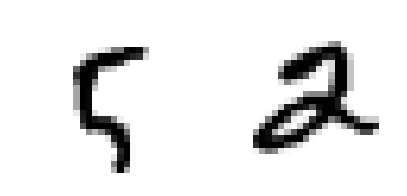

array([ True])

In [9]:
number_2 = X[5]
number_5 = X[100]
number_2_img = number_2.reshape(28,28)
number_5_img = number_5.reshape(28,28)

fig = plt.figure(figsize=(5,10))
ax1 = fig.add_subplot(121)
ax1.imshow(number_5_img, cmap="binary")
ax1.axis("off")
ax2 = fig.add_subplot(122)
ax2.imshow(number_2_img, cmap="binary")
ax2.axis("off")
plt.show()
plt.close("all")

sgd_clf.predict([number_2])
sgd_clf.predict([number_5])



# Implementing Cross-Validation

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

In [11]:
skforld = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skforld.split(x_train, y_train_5):
    clone_clf = clone(sgd_clf)

    # divisão de treinamento
    x_train_folds = x_train[train_index]
    y_train_folds = y_train_5[train_index]

    # divisão de teste
    x_test_folds = x_train[test_index]
    y_test_folds = y_train_5[test_index]

    clone_clf.fit(x_train_folds, y_train_folds)
    y_pred = clone_clf.predict(x_test_folds)
    n_corret = sum(y_pred == y_test_folds)
    print(n_corret/len(y_pred)) # prints 0.9502, 0.96565, and 0.96495


0.9042
0.9477
0.96785


In [12]:
cross_val_score(sgd_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

# Confusion Matrix

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3)
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

# Precicion (TP / TP + FP) and Recall (TP / FN + TP) and F_1 (1/((1/Precition) + (1/score)))

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

precision_score(y_train_5, y_train_pred)
recall_score(y_train_5, y_train_pred)
f1_score(y_train_5, y_train_pred)

#Queremos agora os scores de cada amostra ao inves de uma predição

y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function")

In [64]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

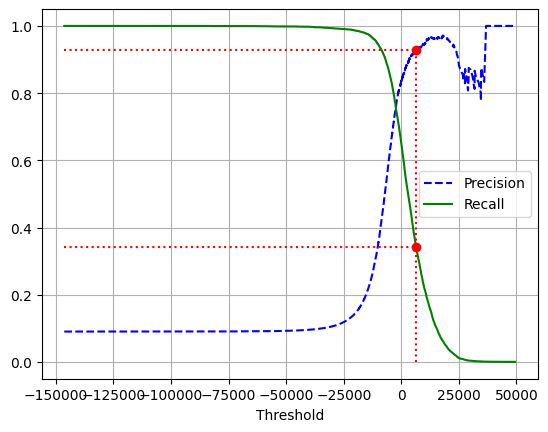

In [77]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds, n):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

    plt.vlines(thresholds[n], 0 ,max(precisions[n], recalls[n]), "red",":")
    plt.hlines(precisions[n], thresholds[0], thresholds[n], "red", ":")
    plt.plot(thresholds[n], precisions[n], "ro")
    plt.hlines(recalls[n], thresholds[0], thresholds[n], "red", ":")
    plt.plot(thresholds[n], recalls[n], "ro")
    plt.legend()
    plt.xlabel("Threshold")
    plt.grid()

    # [...] # highlight the threshold and add the legend, axis label, and grid

plot_precision_recall_vs_threshold(precisions, recalls, thresholds, 58000)
plt.show()

# ROC curve

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)